In [1]:
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.decomposition import PCA

from scipy import stats

import numpy as np
import pandas as pd
import os
import pickle
import statistics

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
import matplotlib
from matplotlib import cm, colors
import seaborn as sns

from gseapy.plot import barplot, dotplot
import gseapy as gp
from gseapy import Msigdb

matplotlib.rc('pdf', fonttype=42)

In [2]:
# Import data

raw = pd.read_csv('../Counts/counts_baseline.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,5:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.head()

,BSSE_QGF_225167,BSSE_QGF_225168,BSSE_QGF_225169,BSSE_QGF_225170,BSSE_QGF_225171,BSSE_QGF_225172,BSSE_QGF_225173,BSSE_QGF_225174,BSSE_QGF_225175,BSSE_QGF_225176,...,BSSE_QGF_225209,BSSE_QGF_225210,BSSE_QGF_225211,BSSE_QGF_225212,BSSE_QGF_225213,BSSE_QGF_225214,BSSE_QGF_225215,BSSE_QGF_225216,BSSE_QGF_225217,BSSE_QGF_225218
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,678,593,433,407,413,541,333,597,769,815,...,556,879,673,494,774,587,563,735,508,898
ENSG00000279928,13,12,6,9,5,14,6,17,12,8,...,0,5,9,15,6,10,3,0,2,13
ENSG00000228037,31,31,16,14,37,30,13,47,46,47,...,27,20,40,45,69,42,46,32,30,65
ENSG00000142611,58,77,38,30,54,40,22,46,118,131,...,48,184,171,80,109,40,32,35,124,80
ENSG00000284616,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [2]:
meta = pd.read_csv('baseline_metadata.csv')
meta.head()

,BiopsyID,Sample_id,Condition,Gender
0,A026,BSSE_QGF_225207,CHC_noHCC,m
1,A351,BSSE_QGF_225206,CHC_noHCC,m
2,A623,BSSE_QGF_225209,CHC_noHCC,m
3,A626,BSSE_QGF_225213,CHC_HCC,m
4,A663,BSSE_QGF_225171,CHC_HCC,m


In [4]:
meta.sort_values('Sample_id')

,BiopsyID,Sample_id,Condition,Gender
45,C641,BSSE_QGF_225167,CHC_noHCC,m
9,A709,BSSE_QGF_225168,CHC_noHCC,m
37,C209,BSSE_QGF_225169,CHC_noHCC,m
26,B354,BSSE_QGF_225170,CHC_noHCC,m
4,A663,BSSE_QGF_225171,CHC_HCC,m
6,A685,BSSE_QGF_225172,CHC_noHCC,m
13,A756,BSSE_QGF_225173,CHC_noHCC,m
12,A750,BSSE_QGF_225174,CHC_noHCC,m
15,A817,BSSE_QGF_225175,CHC_noHCC,f
18,A988,BSSE_QGF_225176,CHC_noHCC,f


In [9]:
# Rename columns
new_cols = {}
for col in meta.iterrows():
    new_cols[col[1].Sample_id] = col[1].BiopsyID
df = raw.rename(new_cols, axis=1)
df.head()

,C641,A709,C209,B354,A663,A685,A756,A750,A817,A988,...,A623,A706,C053,B807,A626,A770,B283,BSSE_QGF_225216,B293,B346
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,678,593,433,407,413,541,333,597,769,815,...,556,879,673,494,774,587,563,735,508,898
ENSG00000279928,13,12,6,9,5,14,6,17,12,8,...,0,5,9,15,6,10,3,0,2,13
ENSG00000228037,31,31,16,14,37,30,13,47,46,47,...,27,20,40,45,69,42,46,32,30,65
ENSG00000142611,58,77,38,30,54,40,22,46,118,131,...,48,184,171,80,109,40,32,35,124,80
ENSG00000284616,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,0


In [30]:
# Filtering

# Create a copy to work on
df_b = df.copy()

# Apply the filter criteria
for col in df_b.columns:
    df_b[col] = np.where(df_b[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_b['Keep'] = np.where(df_b.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_b[df_b.Keep].index

# Return only the rows that were determined to be kept during fitting
df_f = df.loc[keep_indices_].copy()

In [70]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = df_f.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [71]:
#drop nan

df_bt = df_bt.dropna(subset='Biotype')

In [72]:
# Drop columns not included in the study
df_bt = df_bt.drop([x for x in df_bt.columns if x.startswith('BSSE')], axis=1)

In [73]:
# Sorting
df_bt = df_bt[df_bt.columns.sort_values()]
metadata = metadata.sort_index()

## VST normalization for Mitochondrial Genes

In [57]:
# Perform vst normalization

df_bt_t = df_bt.drop('Biotype', axis=1).T

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_bt_t, # Last column is biotype
    metadata=metadata,
    design_factors=['Gender','Condition'], # Sex as a Covariate
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_bt_t)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_bt_t.index, columns=df_bt_t.columns
)
df_t_bt = transformed_counts.T

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_31728\5804213.py:6: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.07 seconds.

Fitting size factors...
... done in 0.07 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 21.68 seconds.



In [58]:
df_t_bt['Biotype'] = df_t_bt.index.map(loaded_dict)
df_t_bt.head()

,A026,A351,A623,A626,A663,A673,A685,A694,A706,A709,...,C293,C362,C373,C436,C454,C473,C641,C801,C861,Biotype
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,9.408681,9.314275,9.295892,9.114479,8.970977,8.937152,9.410344,9.258192,9.656121,9.335289,...,9.299024,9.517103,9.463351,9.418653,9.430447,9.370870,9.562514,8.431395,8.895900,protein_coding
ENSG00000279928,4.354507,4.661644,3.635804,4.453982,4.601277,4.210458,5.237930,4.198862,4.486542,5.031681,...,3.635804,5.098411,4.618484,4.829334,4.333694,4.900680,5.104080,3.635804,5.505011,transcribed_unprocessed_pseudogene
ENSG00000228037,5.679132,6.024344,5.677201,6.126618,6.027879,5.938040,5.872595,6.079787,5.272798,5.768376,...,5.410364,6.089806,5.696237,5.863513,5.530917,5.713277,5.795027,5.891209,5.913944,lncRNA
ENSG00000142611,6.775156,6.217194,6.227616,6.612918,6.417066,4.946835,6.153384,6.347833,7.552797,6.701201,...,6.365486,6.004015,6.162938,6.659551,6.591235,6.986757,6.420077,6.412862,5.994047,protein_coding
ENSG00000157911,9.511887,8.528868,9.438272,8.501887,9.134234,9.079922,8.896932,9.128212,8.731050,9.410544,...,8.935512,9.843327,9.562006,9.376620,8.951709,8.953274,9.320993,9.068429,8.952356,protein_coding


In [59]:
df_t_bt['Biotype'].unique()

array(['protein_coding', 'transcribed_unprocessed_pseudogene', 'lncRNA',
       'transcribed_processed_pseudogene', 'processed_pseudogene', 'TEC',
       'transcribed_unitary_pseudogene', 'unprocessed_pseudogene',
       'misc_RNA', 'snoRNA', 'scaRNA', 'miRNA', 'snRNA',
       'rRNA_pseudogene', 'unitary_pseudogene', 'rRNA', 'IG_V_pseudogene',
       'IG_V_gene', 'IG_C_gene', 'IG_J_gene', 'scRNA', 'vault_RNA',
       'translated_processed_pseudogene', 'TR_V_gene', 'TR_V_pseudogene',
       'TR_D_gene', 'TR_J_gene', 'TR_C_gene', 'IG_C_pseudogene',
       'ribozyme', 'sRNA', 'TR_J_pseudogene', 'IG_J_pseudogene',
       'IG_D_gene', 'artifact', 'Mt_rRNA', 'Mt_tRNA', 'pseudogene'],
      dtype=object)

In [60]:
df_mito = df_t_bt.dropna(subset='Biotype')
# Take protein coding and Mitochondrial genes
df_mito = df_mito[df_mito.Biotype.str.startswith('Mt_') | (df_mito.Biotype == 'protein_coding')].copy()
df_mito.head()

,A026,A351,A623,A626,A663,A673,A685,A694,A706,A709,...,C293,C362,C373,C436,C454,C473,C641,C801,C861,Biotype
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,9.408681,9.314275,9.295892,9.114479,8.970977,8.937152,9.410344,9.258192,9.656121,9.335289,...,9.299024,9.517103,9.463351,9.418653,9.430447,9.370870,9.562514,8.431395,8.895900,protein_coding
ENSG00000142611,6.775156,6.217194,6.227616,6.612918,6.417066,4.946835,6.153384,6.347833,7.552797,6.701201,...,6.365486,6.004015,6.162938,6.659551,6.591235,6.986757,6.420077,6.412862,5.994047,protein_coding
ENSG00000157911,9.511887,8.528868,9.438272,8.501887,9.134234,9.079922,8.896932,9.128212,8.731050,9.410544,...,8.935512,9.843327,9.562006,9.376620,8.951709,8.953274,9.320993,9.068429,8.952356,protein_coding
ENSG00000142655,9.665280,9.843164,10.086192,9.627822,10.082648,9.709134,9.679294,9.580818,9.485695,9.838108,...,9.936195,10.372657,10.380838,9.992115,9.813209,9.723539,9.729535,9.445723,9.684024,protein_coding
ENSG00000149527,9.039847,8.094628,7.902597,6.932449,8.307118,7.040024,7.425037,7.760642,8.715851,7.998963,...,6.963505,7.436024,8.139746,7.014102,8.441718,7.987031,8.123731,7.982015,7.823675,protein_coding


In [61]:
df_mito_ = df_mito.iloc[:,:-1].T # drop biotype
df_mito_ = df_mito_.reset_index(names='BiopsyID')
df_mito_m = df_mito_.melt(id_vars='BiopsyID')
df_mito_m['Group'] = df_mito_m.BiopsyID.map(metadata['Condition'])
df_mito_m.head()

,BiopsyID,Geneid,value,Group
0,A026,ENSG00000160072,9.408681,CHC_noHCC
1,A351,ENSG00000160072,9.314275,CHC_noHCC
2,A623,ENSG00000160072,9.295892,CHC_noHCC
3,A626,ENSG00000160072,9.114479,CHC_HCC
4,A663,ENSG00000160072,8.970977,CHC_HCC


In [66]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_mito_name = df_mito_m.copy()
df_mito_name['Gene'] = df_mito_m['Geneid'].map(loaded_dict)
df_mito_name.Gene = df_mito_name.Gene.replace('', np.nan)
df_mito_name['Gene'] = np.where(df_mito_name.Gene.isnull(), df_mito_name.Geneid, df_mito_name.Gene) # some genes not in mapping, use ID for these
df_mito_name.head()

,BiopsyID,Geneid,value,Group,Gene
0,A026,ENSG00000160072,9.408681,CHC_noHCC,ATAD3B
1,A351,ENSG00000160072,9.314275,CHC_noHCC,ATAD3B
2,A623,ENSG00000160072,9.295892,CHC_noHCC,ATAD3B
3,A626,ENSG00000160072,9.114479,CHC_HCC,ATAD3B
4,A663,ENSG00000160072,8.970977,CHC_HCC,ATAD3B


In [67]:
df_mito_name_ = df_mito_name[df_mito_name.Gene.str.startswith('MT-')].copy() # Take only MT genes
df_mito_name_ = df_mito_name_.sort_values('Gene')

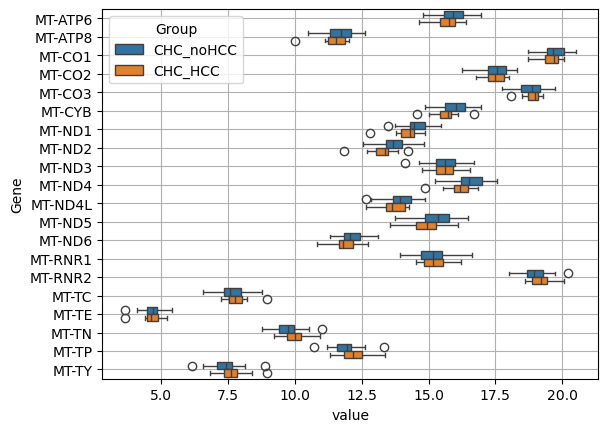

In [68]:
sns.boxplot(df_mito_name_, y='Gene', x='value', hue='Group')
plt.grid()
#plt.savefig('Boxplot_mt_genes_02062025.pdf', bbox_inches='tight', dpi=300)

## Baseline CHC analysis

In [74]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc.index.name = None
df_pc.shape

(17002, 49)

In [75]:
df_pc.head()

,A026,A351,A623,A626,A663,A673,A685,A694,A706,A709,...,C270,C293,C362,C373,C436,C454,C473,C641,C801,C861
ENSG00000160072,624,747,556,774,413,466,541,613,879,593,...,530,682,560,682,806,673,939,678,320,547
ENSG00000142611,82,63,48,109,54,11,40,61,184,77,...,85,67,33,49,95,74,152,58,62,50
ENSG00000157911,672,421,616,494,465,517,373,558,450,626,...,509,524,707,732,782,476,694,570,511,570
ENSG00000142655,750,1091,978,1120,917,813,656,773,778,850,...,1006,1076,1029,1310,1214,885,1209,764,671,966
ENSG00000149527,478,304,198,144,253,108,122,201,445,221,...,283,114,118,258,129,327,338,236,228,245


In [78]:
df_pc.drop('Biotype', axis=1).T.head() # Drop biotype column

,ENSG00000160072,ENSG00000142611,ENSG00000157911,ENSG00000142655,ENSG00000149527,ENSG00000171621,ENSG00000142583,ENSG00000116786,ENSG00000173614,ENSG00000162592,...,ENSG00000276256,ENSG00000273748,ENSG00000277196,ENSG00000278817,ENSG00000278384,ENSG00000276345,ENSG00000275063,ENSG00000277856,ENSG00000271254,ENSG00000277475
A026,624,82,672,750,478,1506,37,2247,715,0,...,444,398,18,44,84,156,1132,255,769,16
A351,747,63,421,1091,304,1670,50,2871,903,2,...,818,160,104,62,493,56,38,32,881,2
A623,556,48,616,978,198,951,50,2299,1047,0,...,252,124,156,193,58,0,102,129,743,7
A626,774,109,494,1120,144,1691,60,3252,1393,6,...,271,414,50,154,72,2,628,204,1224,14
A663,413,54,465,917,253,2071,28,2048,1006,1,...,178,284,10,102,117,336,678,218,604,14


In [79]:
# Perform vst normalization

df_pc_t = df_pc.drop('Biotype', axis=1).T.copy()

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_t,
    metadata=metadata,
    design_factors=['Gender','Condition'], # Sex as covariate
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_t)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_t.index, columns=df_pc_t.columns
)
df_t = transformed_counts.T

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_31728\4252840153.py:6: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.06 seconds.

Fitting size factors...
... done in 0.06 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 13.04 seconds.



# PCA - all genes

In [80]:
# scaled data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_t.T)

In [81]:
pca = PCA(n_components=2)

Text(0, 0.5, 'PC2 (16.08% variance)')

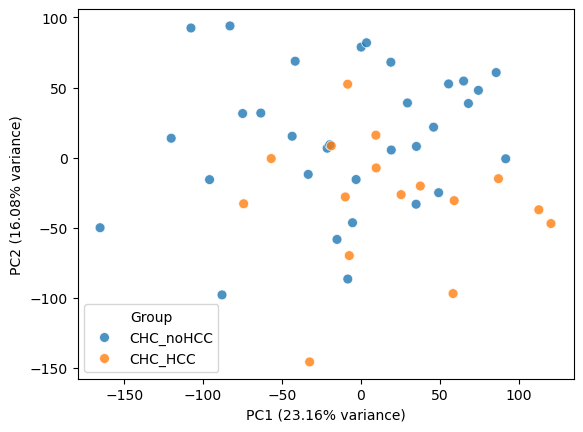

In [82]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=df_t.columns)
df_pca['Group'] = metadata.Condition

fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Group', ax=ax, s=50, alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
#plt.savefig('PCA_all_pc_genes.png', bbox_inches='tight', dpi=300)
#plt.show()

# PCA - top 500

In [83]:
# scaled data

top500 = df_t.copy()
top500['st_dev'] = top500.std(axis=1)
top500 = top500.sort_values('st_dev', ascending=False)
top500 = top500.iloc[0:500,:]
#top500.head()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(top500.iloc[:,:-1].T)

In [84]:
pca = PCA(n_components=2)

Text(0, 0.5, 'PC2 (9.19% variance)')

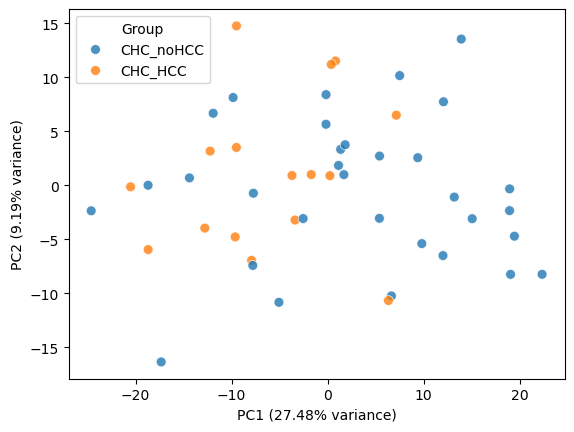

In [85]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=top500.iloc[:,:-1].columns)
df_pca['Group'] = metadata.Condition

fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Group', ax=ax, s=50, alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
#plt.savefig('PCA_top500_pc_genes.png', bbox_inches='tight', dpi=300)
#plt.show()

In [86]:
# Mann Whitney U test
results = stats.mannwhitneyu(x = df_pca[df_pca.Group == 'CHC_noHCC'].PC1.tolist(), y = df_pca[df_pca.Group == 'CHC_HCC'].PC1.tolist())
round(results.pvalue, 3)

np.float64(0.009)

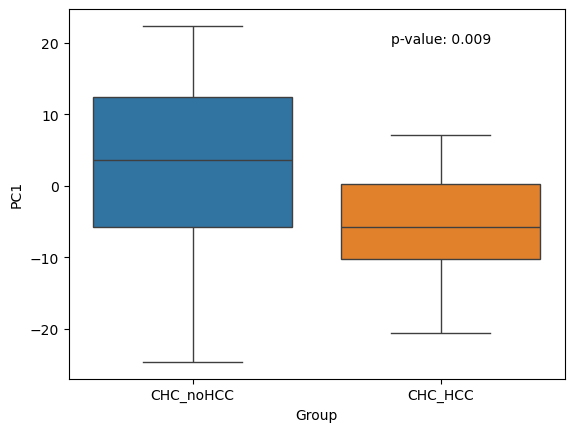

In [87]:
sns.boxplot(data=df_pca, x='Group', y='PC1', hue='Group')
plt.annotate(f'p-value: {round(results.pvalue, 3)}', xy=(.8,20))

plt.savefig('mannwhitneyu_pc1_top500.pdf', dpi=300)

# T-test

In [88]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.08 seconds.

Fitting dispersions...
... done in 13.65 seconds.



In [89]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.08 seconds.

Fitting dispersions...
... done in 12.38 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 23.33 seconds.

Fitting LFCs...
... done in 7.91 seconds.

Calculating cook's distance...
... done in 0.09 seconds.

Replacing 63 outlier genes.

Fitting dispersions...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 0.09 seconds.

Fitting LFCs...
... done in 0.11 seconds.



In [90]:
dds.layers

Layers with keys: normed_counts, _vst_mu_hat, vst_counts, _mu_hat, cooks, replace_cooks

In [92]:
# cooksCutoff=FALSE, independentFiltering=FALSE
# Positive values in CHC-HCC
# contrast = Column, Test, Reference 
ds = DeseqStats(dds, contrast=['Condition', 'CHC_HCC', 'CHC_noHCC'],
                cooks_filter=False, independent_filter=False)
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition CHC_HCC vs CHC_noHCC
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  616.873049       -0.025773  0.091584 -0.281419  0.778389   
ENSG00000142611   65.487625       -0.084880  0.226374 -0.374955  0.707694   
ENSG00000157911  574.547477       -0.184383  0.104349 -1.766974  0.077233   
ENSG00000142655  908.508878       -0.122900  0.093962 -1.307971  0.190883   
ENSG00000149527  231.375953        0.069890  0.222794  0.313696  0.753752   
...                     ...             ...       ...       ...       ...   
ENSG00000276345   67.008708        0.190997  0.893137  0.213850  0.830664   
ENSG00000275063  648.426500        0.529860  0.473278  1.119553  0.262904   
ENSG00000277856  217.721538       -0.732689  0.418511 -1.750703  0.079997   
ENSG00000271254  768.131187       -0.129203  0.142594 -0.906092  0.364887   
ENSG00000277475   11.495656        0.078106  0.382257  0.204329  0.838097   

      

... done in 17.17 seconds.



In [93]:
ds.summary()

Log2 fold change & Wald test p-value: Condition CHC_HCC vs CHC_noHCC
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  616.873049       -0.025773  0.091584 -0.281419  0.778389   
ENSG00000142611   65.487625       -0.084880  0.226374 -0.374955  0.707694   
ENSG00000157911  574.547477       -0.184383  0.104349 -1.766974  0.077233   
ENSG00000142655  908.508878       -0.122900  0.093962 -1.307971  0.190883   
ENSG00000149527  231.375953        0.069890  0.222794  0.313696  0.753752   
...                     ...             ...       ...       ...       ...   
ENSG00000276345   67.008708        0.190997  0.893137  0.213850  0.830664   
ENSG00000275063  648.426500        0.529860  0.473278  1.119553  0.262904   
ENSG00000277856  217.721538       -0.732689  0.418511 -1.750703  0.079997   
ENSG00000271254  768.131187       -0.129203  0.142594 -0.906092  0.364887   
ENSG00000277475   11.495656        0.078106  0.382257  0.204329  0.838097   

      

In [94]:
df_res = ds.results_df
df_res['abs_diff'] = df_res.log2FoldChange.abs()
df_res = df_res.sort_values('abs_diff', ascending=False)
df_res.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000126890,11.924480,33.135340,422.311305,0.078462,0.937461,0.970531,33.135340
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657
ENSG00000172016,3.021590,3.020549,1.979410,1.525984,0.127014,0.317712,3.020549
ENSG00000120952,1.477293,-2.582870,1.365747,-1.891177,0.058601,0.201645,2.582870
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461


In [95]:
# Add Gene Names
with open('C:/Users/Fredrik/Documents/Heim_lab/ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_named = df_res.reset_index(names='Geneid').copy()
    
df_named['Gene'] = df_named['Geneid'].map(loaded_dict)
df_named.Gene = df_named.Gene.replace('', np.nan)
df_named['Gene'] = np.where(df_named.Gene.isnull(), df_named.Geneid, df_named.Gene)
df_named.index = df_named.Geneid
df_named = df_named.drop('Geneid', axis=1)

In [96]:
df_named.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene
Geneid,,,,,,,,
ENSG00000126890,11.924480,33.135340,422.311305,0.078462,0.937461,0.970531,33.135340,CTAG2
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3
ENSG00000172016,3.021590,3.020549,1.979410,1.525984,0.127014,0.317712,3.020549,REG3A
ENSG00000120952,1.477293,-2.582870,1.365747,-1.891177,0.058601,0.201645,2.582870,PRAMEF2
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19


<Axes: xlabel='Condition', ylabel='ENSG00000126890'>

C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


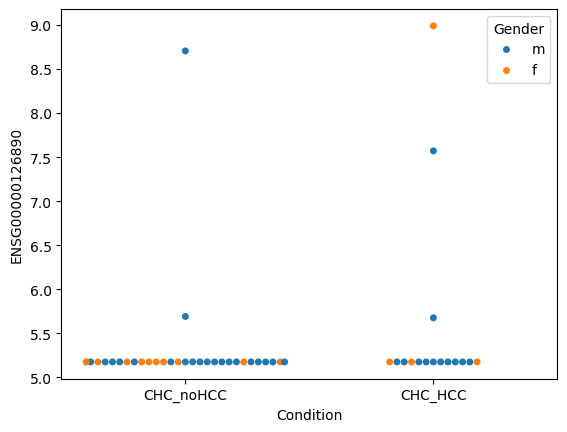

In [97]:
# CTAG2 is an outlier we exclude from visualization 

df_bars = df_t.loc['ENSG00000126890',:].copy()
df_bars = pd.concat([df_bars, metadata.Gender, metadata.Condition], axis=1)
#df_bars
sns.swarmplot(df_bars, x='Condition', y='ENSG00000126890', hue='Gender')

In [121]:
df_sig = df_named[df_named.padj < 0.05].copy()

# Volcano

In [122]:
cmap = [sns.color_palette('tab10')[-1], sns.color_palette('pastel')[7]]

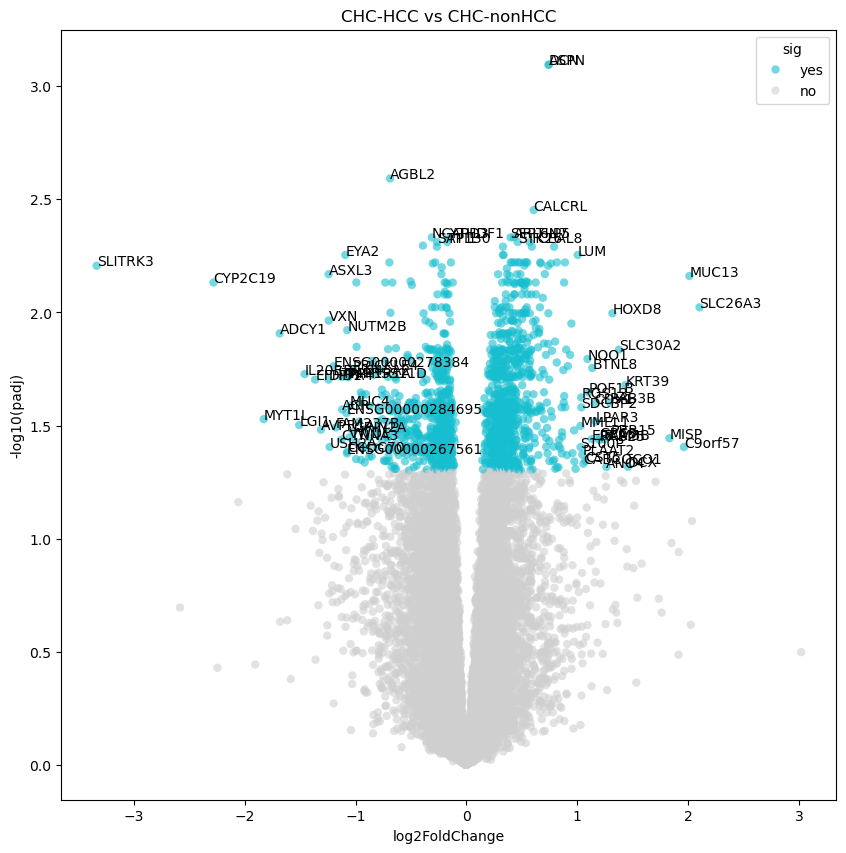

In [123]:
# Volcano

df_volcano = df_named.copy()
# drop X gene
df_volcano = df_volcano[df_volcano.Gene != 'CTAG2']

df_volcano['-log10(padj)'] = -np.log10(df_volcano['padj'])
df_volcano['sig'] = np.where(df_volcano['padj'] < 0.05, 'yes', 'no')


fig, ax = plt.subplots(figsize=(10,10))

sns.scatterplot(df_volcano, x=f'log2FoldChange', y='-log10(padj)', hue='sig',
               alpha=0.6, linewidth=0, ax=ax, palette=cmap, hue_order=['yes', 'no'])

df_highlight = df_volcano[df_volcano.sig == 'yes'].copy()
df_highlight_down = df_highlight[(df_highlight[f'log2FoldChange'] < -1) |\
                            (df_highlight['-log10(padj)'] > 2.3)]

df_highlight_up = df_highlight[df_highlight[f'log2FoldChange'] > 1]


for (label, x, y) in zip(df_highlight_down['Gene'], 
                        df_highlight_down[f'log2FoldChange'],
                        df_highlight_down['-log10(padj)']):
    ax.annotate(label, (x, y))

df_highlight_up = df_highlight_up.sort_values(f'log2FoldChange')
for j, (label, x, y) in enumerate(zip(df_highlight_up['Gene'], 
                        df_highlight_up[f'log2FoldChange'],
                        df_highlight_up['-log10(padj)'])):
    ax.annotate(label, (x, y))

plt.title('CHC-HCC vs CHC-nonHCC')
plt.show()
#plt.savefig(f'Volcano_Baseline_18062025.pdf', bbox_inches='tight', dpi=300)

In [124]:
df_highlight_down.shape

(40, 10)

In [125]:
df_highlight_up.shape

(28, 10)

In [126]:
df_highlight[df_highlight.log2FoldChange.abs() >1].shape

(56, 10)

# Pathway analysis

In [127]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

In [128]:
# Define background set as all identified protein codeing genes
bg_genes = set(df_named['Gene'])
len(bg_genes)

17000

In [129]:
enr_res = gp.enrichr(gene_list=df_sig.Gene.tolist(),
 gene_sets=gmt,
 organism='Homo Sapiens',
 outdir='HM/',
 background=bg_genes,
 )

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_31728\155547990.py:9: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  g = sns.barplot(data=path_res_sig, y='Term', x='-log10(padj)',


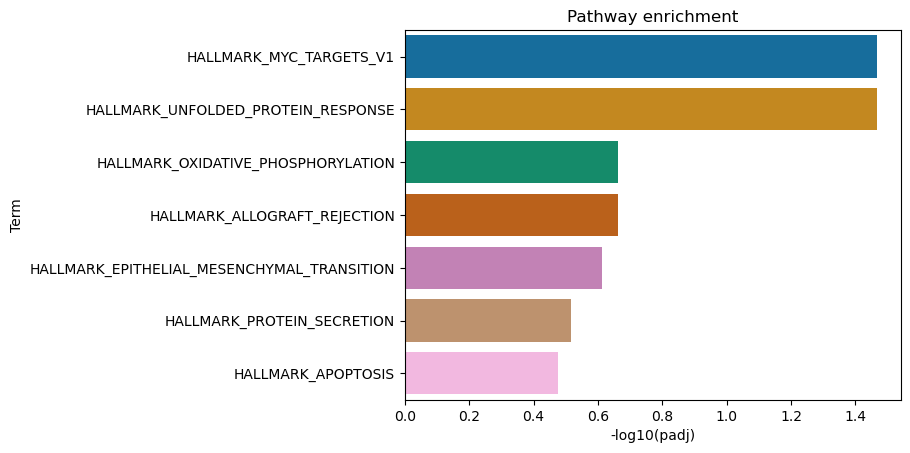

In [130]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
path_res_sig = path_res[path_res['P-value'] < 0.05]

# Barplot
g = sns.barplot(data=path_res_sig, y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

plt.title('Pathway enrichment')
#plt.savefig(f'Reactome_pathway_enrichment_padj_00001.png', bbox_inches='tight', dpi=300)
plt.show()

In [131]:
# Extract genes in each pathway
pathway_genes = {}
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

In [132]:
# Add Gene Names back
    
df_t_n = df_t.reset_index(names='Geneid').copy()
    
df_t_n['Gene'] = df_t_n['Geneid'].map(loaded_dict)
df_t_n.Gene = df_t_n.Gene.replace('', np.nan)
df_t_n['Gene'] = np.where(df_t_n.Gene.isnull(), df_t_n.Geneid, df_t_n.Gene)
df_t_n.index = df_t_n.Geneid
df_t_n = df_t_n.drop('Geneid', axis=1)

C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 8.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Fredrik\miniconda3\envs\EDA\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


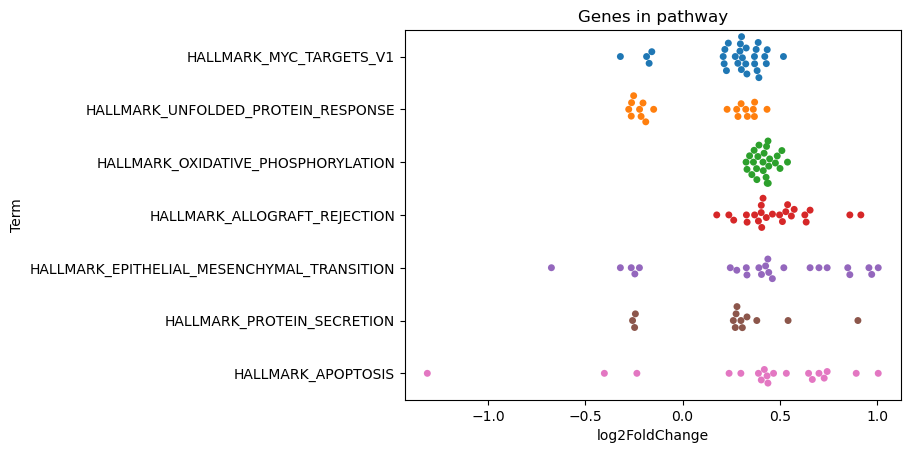

In [133]:
# Plot fold-change of genes identified in pathway enrichment

genes_list = []
for i in range(0,7):
    path = path_res_sig.Term[i]
    genes = pathway_genes[path]

    gene_data = df_sig[df_sig.Gene.isin(genes)].log2FoldChange
    genes_list.append(gene_data)
    
df_path_genes = pd.concat(genes_list, axis=1)
df_path_genes.columns = path_res_sig.Term[0:7]
df_path_genes.head()

sns.swarmplot(data=df_path_genes, orient='h')
plt.title('Genes in pathway')
plt.xlabel('log2FoldChange')
plt.show()

#plt.savefig('fold_change_pathway_genes_hm_290425.pdf', dpi=300, bbox_inches='tight')


In [134]:
# Plot each pathway gene as a violinplot (not used in paper)

import math  # Needed for calculating rows

df_path_genes = []

for i in range(0, 5):  # Iterate over pathways
    path = path_res.Term[i]
    genes = pathway_genes[path]
    num_genes = len(genes)  # Number of genes in the pathway
    
    all_gene_data = []

    if num_genes == 0:
        continue  # Skip if no genes

    # Determine grid size (max 5 columns, calculate rows dynamically)
    num_cols = min(4, num_genes)  # Max 5 plots per row
    num_rows = math.ceil(num_genes / num_cols)  # Calculate required rows

    # Create figure and subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows), sharex=True)
    fig.suptitle(f"Pathway: {path}", fontsize=16)

    # Flatten axes array if there are multiple rows
    axes = axes.flatten() if num_genes > 1 else [axes]

    for ax, gene in zip(axes, genes):
        gene_data = df_t_n[df_t_n.Gene == gene].T
        gene_data = pd.concat([gene_data.iloc[:-1, :], metadata.Condition], axis=1)
        gene_data.columns = [gene, 'Condition']

        # Extract fold change and adjusted p-value
        fold_change = df_sig[df_sig.Gene == gene].log2FoldChange.values
        padj = df_sig[df_sig.Gene == gene].padj.values

        # Format values for display
        fold_change_text = f"{fold_change[0]:.2f}" if len(fold_change) > 0 else "N/A"
        padj_text = f"{padj[0]:.2e}" if len(padj) > 0 else "N/A"

        # Create violin plot
        sns.violinplot(data=gene_data, x='Condition', y=gene, ax=ax, hue='Condition', fill=False)
        ax.set_title(f"{gene}\nlog2FC: {fold_change_text}, p_adj: {padj_text}", loc='left', fontsize=16)
        ax.set(ylabel='')
        
       
        all_gene_data.append(gene_data[gene])

    # Hide unused subplots if any
    for j in range(len(genes), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit title
    plt.savefig(f'{path}_gene_expression.pdf', bbox_inches='tight', dpi=300)
    plt.close()
    
    df_path_genes.append(pd.concat(all_gene_data, axis=1))


In [135]:
# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]

In [137]:
df_sig['Hallmark'] = df_sig.Gene.map(hm_dict)
df_sig.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark
Geneid,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN
ENSG00000091138,76.030001,2.103508,0.522340,4.027084,0.000056,0.009489,2.103508,SLC26A3,NaN
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN
ENSG00000204669,4.034931,1.963120,0.648626,3.026583,0.002473,0.039375,1.963120,C9orf57,NaN


In [138]:
# Same with Reactome (not used in paper)

react_dict = {}

for row in path_res_sig.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in react_dict.keys():
            prev_term = react_dict[gene]
            prev_term.append(term)
            react_dict[gene] = prev_term
        else:
            react_dict[gene] = [term]

In [139]:
df_sig['Reactome'] = df_sig.Gene.map(react_dict)
df_sig.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,Hallmark,Reactome
Geneid,,,,,,,,,,
ENSG00000121871,48.448299,-3.335657,0.770559,-4.328879,0.000015,0.006215,3.335657,SLITRK3,NaN,NaN
ENSG00000165841,3634.976924,-2.281461,0.547173,-4.169545,0.000031,0.007373,2.281461,CYP2C19,NaN,NaN
ENSG00000091138,76.030001,2.103508,0.522340,4.027084,0.000056,0.009489,2.103508,SLC26A3,NaN,NaN
ENSG00000173702,362.609388,2.012033,0.473098,4.252890,0.000021,0.006900,2.012033,MUC13,NaN,NaN
ENSG00000204669,4.034931,1.963120,0.648626,3.026583,0.002473,0.039375,1.963120,C9orf57,NaN,NaN


In [143]:
df_sig.shape

(1347, 10)

In [140]:
df_sig.to_csv('Baseline_sig_degs_with_hm_reactome_251125.csv')